# MAG Skill‑Box Extraction Demo
This notebook demonstrates how to use `extract_mag_boxes.py` to cut the FIG **Men’s Artistic Gymnastics 2025‑2028 Code of Points** PDF into individual skill‑box images.

Make sure you have the PDF (`en_1.1 - MAG CoP 2025-2028.pdf`) and the script (`extract_mag_boxes.py`) in the same directory as this notebook.

## 1  Install / update the required libraries
`PyMuPDF`, `opencv‑python`, and `numpy` will be installed inside your active environment.

In [1]:
# If running inside a fresh env, uncomment the next line
# !pip install -r requirements.txt --quiet
import sys, subprocess, pkg_resources, os, importlib, pathlib, textwrap
print('Python', sys.version)


Python 3.9.7 (default, Sep 16 2021, 08:50:36) 
[Clang 10.0.0 ]


## 2  Run the extractor 🔪

In [1]:
%load_ext autoreload
%autoreload 2

import subprocess, pathlib, sys, os, shlex, time, json, pprint, runpy
import fitz
from extract_mag_boxes import process_page


PDF = "en_1.1 - MAG CoP 2025-2028.pdf"
OUT_DIR = "skills_demo"

doc = fitz.open(PDF)
total_saved = 0


page_num = 28

page = doc[page_num - 1]
saved_files = process_page(page, page_num, OUT_DIR)
total_saved += len(saved_files)
print(saved_files)




[{'items': [('c', Point(425.0716247558594, 549.2540893554688), Point(425.0716247558594, 544.02099609375), Point(429.3115234375, 539.782958984375), Point(434.5451965332031, 539.782958984375)), ('c', Point(434.5451965332031, 539.782958984375), Point(439.77886962890625, 539.782958984375), Point(444.0045471191406, 544.02099609375), Point(444.0045471191406, 549.2552490234375)), ('c', Point(444.0045471191406, 549.2552490234375), Point(444.0045471191406, 554.4895629882812), Point(439.7693786621094, 558.7169189453125), Point(434.5451965332031, 558.7169189453125)), ('c', Point(434.5451965332031, 558.7169189453125), Point(429.3210144042969, 558.7169189453125), Point(425.0716247558594, 554.4801025390625), Point(425.0716247558594, 549.2540893554688))], 'closePath': False, 'type': 's', 'stroke_opacity': 1.0, 'color': (0.0, 0.0, 0.0), 'width': 1.0, 'lineCap': (0, 0, 0), 'lineJoin': 0.0, 'dashes': '[] 0', 'rect': Rect(425.0716247558594, 539.782958984375, 444.0045471191406, 558.7169189453125), 'layer'

In [21]:
import fitz  # PyMuPDF
from pprint import pprint

PDF_PATH = "en_1.1 - MAG CoP 2025-2028.pdf"
PAGE_NUM = 28          # <-- 1‑based; change to a page you expect is 4×6

doc   = fitz.open(PDF_PATH)
page  = doc[PAGE_NUM-1]

# get_drawings() returns paths, fills, strokes, images, etc.
drawings = page.get_drawings()

print(f"Page {PAGE_NUM}: found {len(drawings)} drawing objects\n")
for i, d in enumerate(drawings[:10]):       # peek at first 10
    print(f"[{i}] type={d['type']}  items={len(d['items'])}  color={d['color']}")

Page 28: found 226 drawing objects

[0] type=s  items=4  color=(0.0, 0.0, 0.0)
[1] type=s  items=1  color=(0.0, 0.0, 0.0)
[2] type=s  items=1  color=(0.0, 0.0, 0.0)
[3] type=s  items=2  color=(1.0, 1.0, 1.0)
[4] type=s  items=2  color=(0.0, 0.0, 0.0)
[5] type=s  items=2  color=(0.0, 0.0, 0.0)
[6] type=s  items=2  color=(0.0, 0.0, 0.0)
[7] type=s  items=2  color=(0.0, 0.0, 0.0)
[8] type=s  items=2  color=(0.0, 0.0, 0.0)
[9] type=s  items=2  color=(0.0, 0.0, 0.0)


In [22]:
# Count occurrences of each drawing type
type_counts = {}
for d in drawings:
    d_type = d['type']
    type_counts[d_type] = type_counts.get(d_type, 0) + 1

print("\nDrawing type counts:")
for d_type, count in type_counts.items():
    print(f"{d_type}: {count}")



Drawing type counts:
s: 27
f: 198
fs: 1


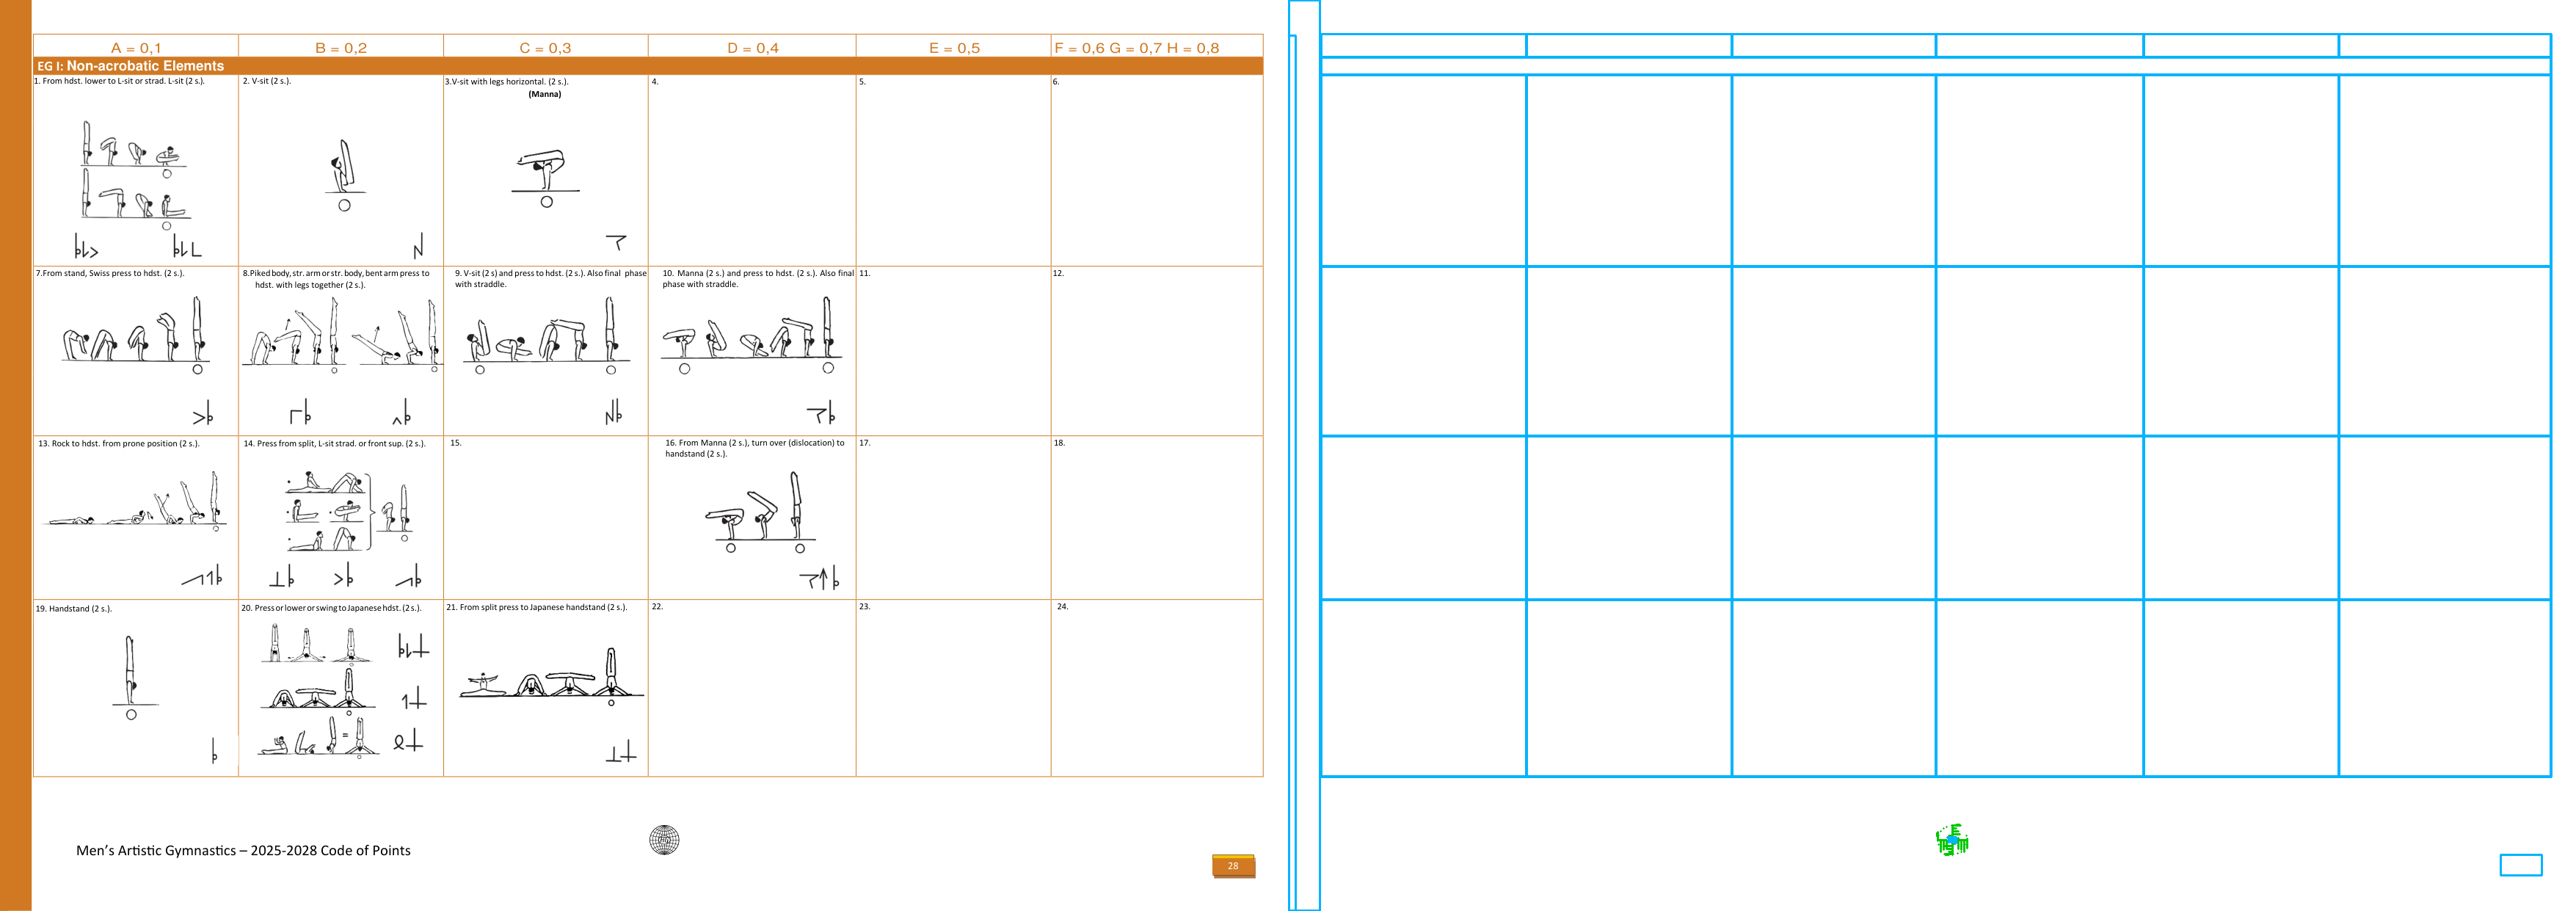

In [ ]:
import fitz, numpy as np, cv2
from PIL import Image                # <-- change this line
from IPython.display import display

# ---------- config ----------
PDF_PATH = "en_1.1 - MAG CoP 2025-2028.pdf"
PAGE_NUM = 28          # <‑‑ choose any 4×6 skill page
DPI      = 150
# -----------------------------

doc   = fitz.open(PDF_PATH)
page  = doc[PAGE_NUM-1]

# 1) original page bitmap (for reference)
pix   = page.get_pixmap(dpi=DPI, alpha=False)
h, w  = pix.height, pix.width
orig  = np.frombuffer(pix.samples, dtype=np.uint8).reshape(h, w, 3)

# 2) blank white canvas
canvas = np.ones_like(orig) * 255      # white background

scale = DPI / 72.0                     # PDF points –> pixels

# 3) iterate drawing objects
for d in page.get_drawings():
    typ = d["type"]
    if typ not in {"s", "f", "fs", "b"}:
        continue                       # skip text glyphs, images, etc.

    is_fill  = typ in {"f", "fs", "b"}
    color = (0, 180, 255) if is_fill else (0, 200, 0)   # BGR (orange / green)

    for seg in d["items"]:
        try:    
            cmd = seg[0]
            # rectangles come as ('re', Rect(...), -1)
            if cmd == "re":
                r = seg[1]
                x0, y0, x1, y1 = int(r.x0*scale), int(r.y0*scale), int(r.x1*scale), int(r.y1*scale)
                cv2.rectangle(canvas, (x0, y0), (x1, y1),
                               color if is_fill else (0, 200, 0), 2)
            else:
                # generic line segment: ((x0,y0),(x1,y1),'l' or 'c' etc.)
                (x0,y0),(x1,y1) = seg[1], seg[2]
                x0, y0 = int(x0*scale), int(y0*scale)
                x1, y1 = int(x1*scale), int(y1*scale)
                cv2.line(canvas, (x0, y0), (x1, y1), color, 2)
        except Exception as e:
            print(f"Error processing segment: {e}")
            print(seg)

# 4) show side‑by‑side
side = np.hstack([orig, canvas])
display(Image.fromarray(side))


## 3  Preview a few extracted images

In [ ]:
from pathlib import Path
from IPython.display import display, Image
samples = sorted(Path('skills_demo').glob('*.png'))[:8]
for p in samples:
    display(Image(filename=str(p)))


Feel free to change `DPI`, toggle `--debug`, or tweak the script options and re‑run cells to experiment.